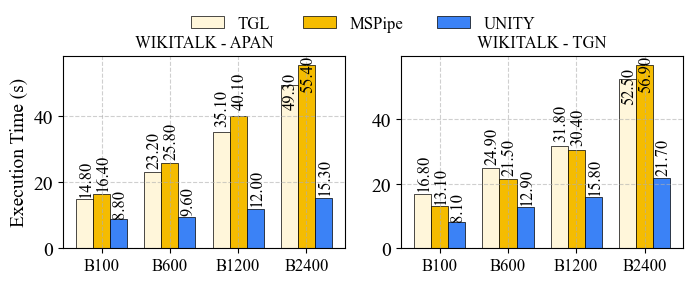

In [1]:
import yaml
import numpy as np
import mycolors
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

plt.rcParams['font.family'] = 'Times New Roman'

# 读取 YAML 文件
yaml_file = "batch_size.yaml"
with open(yaml_file, "r") as file:
    batch_data = yaml.safe_load(file)

# 设定子图结构
fig = plt.figure(figsize=(8, 2.5))
outer_gs = gridspec.GridSpec(1, 2, wspace=0.2, hspace=0.3)

# 定义颜色方案
# colors = [mycolors.LADDER_ORDER.LIGHT_GRAY, mycolors.MALOPE.PURPLE, mycolors.LADDER_ORDER.LIGHT_GREEN]
colors = ['#FFF6da','#F5BC00','#3B82F6']
baseline_labels = ["TGL", "MSPipe", "UNITY"]
handles, labels = [], []

# 遍历数据集和模型进行绘图
for row_idx, (dataset, models) in enumerate(batch_data.items()):
    for col_idx, (model, values) in enumerate(models.items()):
        ax = fig.add_subplot(outer_gs[row_idx, col_idx])
        
        # 设定 x 轴
        batch_sizes = list(values["TGL"].keys())
        x_base = np.arange(len(batch_sizes))
        bar_width = 0.25
        
        # 绘制不同的 baseline
        for baseline_idx, baseline in enumerate(baseline_labels):
            x_offset = x_base + (baseline_idx - 1) * bar_width
            heights = [values[baseline][bs] for bs in batch_sizes]
            bars = ax.bar(x_offset, heights, width=bar_width, color=colors[baseline_idx],
                          edgecolor='black', linewidth=0.5, alpha=1, label=baseline if row_idx == 0 and col_idx == 0 else "")
            
            # 添加数据标签
            for bar in bars:
                height = bar.get_height()
                label_height = height * 1.05
                if label_height > ax.get_ylim()[1]*0.8:  # 如果超出了 y 轴范围
                    label_height = height * 0.85  # 将标签放在柱子顶端的下方
                
                ax.text(bar.get_x()+0.1*bar_width + bar.get_width()/2., label_height,
                        f'{height:.2f}', ha='center', va='bottom', fontsize=12, rotation=90)
        
        # 设置子图属性
        ax.set_title(f"{dataset} - {model}", fontsize=12)
        ax.set_xticks(x_base)
        ax.set_xticklabels(batch_sizes, rotation=0, ha='center', fontsize=12)
        ax.tick_params(axis='y', labelsize=14)
        ax.grid(True, which='both', linestyle='--', alpha=0.6)
        
        if col_idx == 0:
            ax.set_ylabel('Execution Time (s)', fontsize=14)

        h, l = ax.get_legend_handles_labels()
        handles.extend(h)
        labels.extend(l)

# 添加统一图例
unique_legend = dict(zip(labels, handles))
fig.legend(unique_legend.values(), unique_legend.keys(), loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.10), fontsize=12, frameon=False)

plt.savefig('exp3.pdf', bbox_inches='tight')

# 显示图像
plt.show()